# Human in the loop

그래프 중간 과정에서 사용자의 응답을 요청하는 방식
- `interrupt` : 해당 시점에 실행을 중단함
- `Command(resume)` : 재개할 때에는 `Command(resume)` 을 사용
- `Command(goto)` : 다른 위치로 이동 시에 사용

## 환경설정 및 Jupyter 설치
### 가상환경 세팅
```bash
conda create --name env-langgraph-fc python=3.10 -y
```
<br/>

### 세팅 확인
가상환경 디렉터리 확인
```bash
ls -al ~/miniforge3/envs/env-langgraph-fc 
```
<br/>

가상환경 활성화
```bash
conda activate env-langgraph-fc
```
<br/>

가상환경을 끌때는 다음과 같이 한다.
```bash
conda deactivate
```
<br/>

### 의존성 설정
먼저 jupyter 설치
```bash
# pip 대신 mamba를 사용하면 패키지 설치 속도가 훨씬 빠릅니다.
mamba install -c conda-forge jupyter notebook ipykernel -y
```
<br/>

다음 의존성 설치
```bash
## pip 를 이용해 설치
!pip install langgraph langchain langchain_google_genai langchain_community

## 또는 mamba 를 이용해 설치
mamba install langgraph langchain langchain_google_genai langchain_community
```
<br/>

keyring 라이브러리 설치
```bash
## pip 을 이용해 설치
pip install keyring

## 또는 mamba 를 이용해 keyring 설치
mamba install keyring
```
<br/>

## keyring import (api key 설정)
- (1) 미리 터미널에 입력해둔다.
- (2) python 코드 내에서 사용한다.

```bash
## bash 쉘 에서 다음 내용을 입력
## 형식 keyring set {{서비스명}} {{계정명}}

## e.g.
keyring set gemini-api-key---alpha300uk alpha300uk  
Password for 'alpha300uk' in 'gemini-api-key---alpha300uk':
```

In [2]:
import keyring
gemini_service_name = "gemini-api-key---alpha300uk"
gemini_username = "alpha300uk"
gemini_api_token = keyring.get_password(gemini_service_name, gemini_username)

tavily_service_name = "tavily-api-key---alpha300uk"
tavily_username = "alpha300uk"
taviliy_api_token = keyring.get_password(tavily_service_name, tavily_username)

langsmith_service_name = "langsmith-api-key---alpha300uk"
langsmith_username = "alpha300uk"
langsmith_api_token = keyring.get_password(langsmith_service_name, langsmith_username)

naver_service_name = "naver-api-key---eTurJdj3Z3s9en2hLTWK" ## 접미사는 Client ID 로 지정 
naver_username = "eTurJdj3Z3s9en2hLTWK"
naver_api_token = keyring.get_password(naver_service_name, naver_username)

## 의존성 설치 (혹시 설치 안했을 경우를 위해 추가한 섹션)

In [12]:
!pip install langgraph langchain langchain_google_genai langchain-tavily rich -q
### ! pip install langgraph langchain langchain_google_genai langchain_community

## llm, ratelimiter 선언

In [4]:
## llm, ratelimiter 선언
import os
os.environ['GOOGLE_API_KEY'] = gemini_api_token

from langchain_core.rate_limiters import InMemoryRateLimiter
from langchain_google_genai import ChatGoogleGenerativeAI

# Gemini API는 분당 10개 요청으로 제한
# 즉, 초당 약 0.167개 요청 (10/60)
rate_limiter = InMemoryRateLimiter(
    # requests_per_second=0.167,  # 분당 10개 요청
    requests_per_second=1,  # 초당 최대 1개, 분당 최대 60개 요청
    check_every_n_seconds=0.1,  # 100ms마다 체크
    max_bucket_size=10,  # 최대 버스트 크기
)

# rate limiter를 LLM에 적용
llm = ChatGoogleGenerativeAI(
    model="gemini-2.5-flash",
    rate_limiter=rate_limiter,
    # temperature
    # max_tokens

    thinking_budget = 500  # 추론(Reasoning) 토큰 길이 제한
)

## API key 세팅

In [5]:
os.environ['LANGCHAIN_API_KEY'] = langsmith_api_token
os.environ['LANGCHAIN_PROJECT'] = 'LangGraph_FastCampus'
os.environ['LANGCHAIN_ENDPOINT'] = 'https://api.smith.langchain.com'
os.environ['LANGCHAIN_TRACING_V2']='true'

## 네이버 블로그 검색 tool 구성
네이버의 검색 API를 이용해, 블로그 검색을 연결하겠습니다.   
(https://developers.naver.com/apps/#/register?defaultScope=search)

In [6]:
import os
import sys
import urllib.request
import json
from langchain_core.tools import tool

from typing_extensions import TypedDict, Literal, Annotated

headers = {
    'X-Naver-Client-Id': naver_username,
    'X-Naver-Client-Secret': naver_api_token
}

@tool
def search_blogs(query: str, display : int = 10, sort : Literal['sim', 'date'] = 'sim') -> list:
    """네이버 블로그 검색을 수행하여 검색 결과를 리스트로 반환합니다.
    query: 검색어
    display: 검색 결과 개수
    sort: sim(관련도순), date(시간순)
    """

    client_id = headers['X-Naver-Client-Id']
    client_secret = headers['X-Naver-Client-Secret']

    encText = urllib.parse.quote(query)
    url = f"https://openapi.naver.com/v1/search/blog?query={encText}&display={display}"

    request = urllib.request.Request(url)
    request.add_header("X-Naver-Client-Id", client_id)
    request.add_header("X-Naver-Client-Secret", client_secret)

    response = urllib.request.urlopen(request)
    rescode = response.getcode()

    if rescode == 200:
        response_body = response.read()
        data = json.loads(response_body.decode('utf-8'))

        # 필요한 데이터 추출
        blog_list = [
            {
                "title": item["title"].replace("<b>", "").replace("</b>", ""),  # 태그 제거
                "link": item["link"],
                "description": item["description"].replace("<b>", "").replace("</b>", ""),
                "postdate": item["postdate"]
            }
            for item in data.get("items", [])
        ]

        return blog_list
    else:
        return ['에러 발생, 다른 검색어로 다시 시도하세요.']


tool_list = [search_blogs]
llm_with_tools = llm.bind_tools(tool_list)

llm_with_tools.invoke("안녕")

AIMessage(content='안녕하세요! 무엇을 도와드릴까요?', additional_kwargs={}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019d3202-c241-7191-ab0b-590c91b2bd77-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 118, 'output_tokens': 8, 'total_tokens': 126, 'input_token_details': {'cache_read': 0}})

### 1. 도구 정의 및 바인딩 테스트

그래프를 본격적으로 구성하기에 앞서, **LLM이 도구 목록을 정확히 인식하고 호출할 수 있는지**를 확인하는 단계입니다.

- **`tool_list = [search_blogs]`**: 에이전트가 사용할 수 있는 도구들을 정의합니다.
- **`llm_with_tools = llm.bind_tools(tool_list)`**: 
    - 정의된 `tool_list` 안의 도구 설명(Docstring)과 파라미터 정보를 LLM에게 함께 전달합니다. 
    - 이로써 LLM은 해당 도구들을 언제 써야 할지 알 수 있는 상태가 됩니다.
- **`llm_with_tools.invoke("안녕")`**: 
    - LLM에게 실제 메시지를 던져 **도구 호출이 일어나는지(Tool Call 발생 여부)**를 테스트합니다. 
    - "안녕"과 같은 일반적인 인사는 도구 호출 없이 일반 텍스트가 반환되는 것이 정상입니다.

> [!NOTE]
> 이 코드는 그래프 실행(`graph.invoke`)이 아닌, **LLM 모델이 도구 요청 형식을 갖추었는지를 확인하는 단독 호출**입니다.


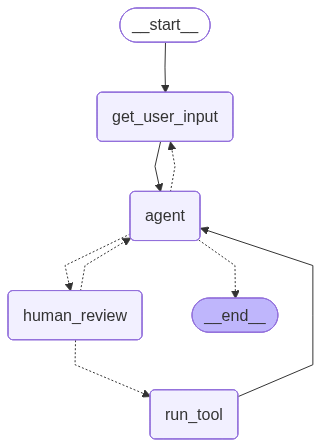

In [8]:
### 자료구조 선언 및 정의
from langgraph.graph.message import add_messages

# query와 messages를 저장
class State(TypedDict):
    query : str
    messages : Annotated[list, add_messages]


### 
from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import MemorySaver
from langgraph.types import Command, interrupt
from langchain_core.messages import AIMessage, HumanMessage, SystemMessage


### 사용자 입력을 받아서 HumanMessage로 만든다
def get_user_input(state):
    human_message = input()
    return {'messages':[HumanMessage(content = human_message)]}

### SystemMessage 생성 후 llm.invoke 수행하고 그 결과값과 state["messages"]를 결합
def agent(state):
    system_message = SystemMessage(content='''당신은 검색 및 요약 챗봇입니다.
사용자의 질문을 해결하기 위해 검색 툴을 사용하고, 해당 결과를 바탕으로 답변하세요.
요청을 해결한 다음에는 마지막에 '감사합니다! 챗봇을 종료합니다!'를 출력하세요.''')

    return {"messages": [llm_with_tools.invoke([system_message] + state["messages"])]}

### ReACT 에이전트를 직접 수작업으로 만든 것
def run_tool(state):
    new_messages = []
    last_message = state["messages"][-1]

    tools = {tool.name:tool for tool in tool_list}

    tool_calls = last_message.tool_calls

    ### tool_call 각각에 대해
    for tool_call in tool_calls:
        ### 각각에 맞는 tool 을 꺼내고
        tool = tools[tool_call["name"]]
        ### llm 이 실행하도록 invoke 한다.
        result = tool.invoke(tool_call)
        # ToolMessage
        new_messages.append(result)
    return {"messages": new_messages}


"""
(1) run tool 을 하게 해줄 것이냐?
(2) 못하고 다시 agent 로 보낼 것이냐? 
(3) 아니면 run tool 을 하긴 하는데 다른 내용으로 하게 할 것이냐?

e.g. 네이버 검색
(1) 그대로 검색해 (통과)
(2) 아니야 검색이 마음에 안들어. 이걸로 검색해 (검색어만 입력)
(3) 아니야 그냥 해 라는 자연어 요청 (아예 자연어로된 피드백)
"""
### Human Review
# Typing Hint를 연결하면 Graph에 표시됨
def human_review(state) -> Command[Literal["agent", "run_tool"]]:

    # !!중요!!
    # Human_review가 실행되는 상황은 언제일까요?
    # Tool을 실행하기 전이므로, 이 상태의 Context는 항상 [..., AIMessage(content, tool_calls)]
    ### tool_calls 를 꺼낸다 
    ### (tool 을 실행하기 전이므로 AIMessage가 있고, AImessage 내에는 항상 tool_calls 가 들어있다)

    last_message = state["messages"][-1] # tool call 포함된 AIMessage
    tool_call = last_message.tool_calls[-1]

    ### 중단한다. 중단을 재개하는 것은 Command 를 통해 재개
    # inturrupt로 중단된 결과는 Command를 통해 재개
    human_review = interrupt(
        {
            "question": "이대로 진행할까요?",
            "tool_call": tool_call,
        }
    )
    review_action = human_review["action"]
    review_data = human_review.get("data")

    print('Decision:', review_action, '\n Content:', review_data)


    # 그대로 진행하는 경우, run_tool로 진입
    if review_action == "continue":
        return Command(goto="run_tool")

    # update가 필요한 경우, review_data를 args에 넣고 run_tool로 진입
    ## args 를 review_data 로 덮어쓴다.
    elif review_action == "update":
        updated_message = {
            "role": "ai",
            "content": last_message.content,
            "tool_calls": [
                {
                    "id": tool_call["id"],
                    "name": tool_call["name"],

                    "args": review_data, ## 검색어 쓰지 말고 'review_data'를 써라 
                    # 새로운 입력
                }
            ],
            "id": last_message.id, ## 메시지의 id 를 last_message.id 로 변경
            # 메시지 id를 동일하게 설정해 Override
        }
        ## run_tool 로 이동, message 는 위에서 업데이트한 값들로해서 run_tool 로 goto
        return Command(goto="run_tool", update={"messages": [updated_message]})


    ### review 데이터가 "아냐, 안할래." 같은 단순 구어체일 때 "feedback"으로 분류된다.
    # Feedback: 단순 언어로 피드백을 전달하고 싶은 경우
    elif review_action == "feedback":

        # Tool Call 요청을 새로운 유저 메시지로 대체합니다.
        ### content 는 review_data 로 내용을 대체하지만, id 는 last_message.id 로 유지해서, 이전 과정을 다시한다
        new_human_message = HumanMessage(content = review_data,
        id = last_message.id)

        ### agent 로 goto 한다. (HumanMessage를 소비하는 것은 agent 이기에 agent 로 goto 하도록 정의)
        return Command(goto="agent", update={"messages": [new_human_message]})


def route_after_llm(state) -> Literal[END, "get_user_input", "human_review"]:

    last_message = state['messages'][-1]
    # 마지막 메시지: tool calling
    # 2025.10.26 업데이트: Gemini의 Thinking 모델(2.5 이후)에는
    # Tool Calling 이후의 messages에 signature가 포함되어 형식이 달라집니다.
    last_message_content = last_message.content

    if not last_message.tool_calls:
        # if '감사합니다! 챗봇을 종료합니다!' in last_message_content:
        if '챗봇을 종료' in last_message_content: ## 어쩌다 가끔은 llm 이 '감사합니다! 챗봇을 종료합니다!!' 같은 메시지가 아니라 유사한 메시지로 응답하는 경우가 있기에 '챗봇을 종료'라는 단어가 있는지 검사해야 할 경우도 있다.
            return END
        elif isinstance(last_message_content[0], dict) and 'text' in last_message_content[0] and '감사합니다! 챗봇을 종료합니다!' in last_message_content[0]['text']:
            return END
        return 'get_user_input'
    else:
        return "human_review"


builder = StateGraph(State)
builder.add_node(get_user_input)
builder.add_node(agent)
builder.add_node(run_tool)
builder.add_node(human_review)

builder.add_edge(START, "get_user_input")
builder.add_edge('get_user_input', "agent")
builder.add_conditional_edges("agent", route_after_llm) 
## graph 를 보면 route_after_llm 은 노드로 나타나지 않는다.
## route_after_llm 은 node 로 등록하지 않고, 
builder.add_edge("run_tool", "agent")

memory = MemorySaver()

graph = builder.compile(checkpointer=memory)
# 중간 상태 저장을 위해 체크포인터가 필요합니다!
graph

### Human-in-the-loop (에이전트 제어 및 승인)

이 워크플로우는 에이전트가 도구(Tool)를 실행하기 직전에 **사람의 승인을 받거나 인자값을 수정**할 수 있는 강력한 제어 기능을 제공합니다.

#### 1. 핵심 노드 설명
- **`get_user_input`**: 사용자로부터 초기 질문이나 추가 피드백을 직접 입력받습니다.
- **`agent`**: 질문을 분석하고, 필요한 도구가 있다면 호출(`tool_calls`)을 시도합니다.
- **`human_review` (HITL의 핵심)**:
    - **`interrupt`**: 도구 호출 시점에 그래프 실행을 **일시 중지**하고 사용자의 응답을 기다립니다.
    - **`Command`**: 사람의 판단(`continue`, `update`, `feedback`)에 따라 다음 경로를 결정합니다.
        - **승인(`continue`)**: 그대로 도구 실행(`run_tool`) 노드로 이동.
        - **수정(`update`)**: 사람의 수정된 인자값으로 도구를 실행.
        - **피드백(`feedback`)**: 도구 호출 대신 사람의 의견을 다시 에이전트에게 전달.

#### 2. 흐름 제어(`route_after_llm`) 및 분기 원리
에이전트(LLM)가 응답한 **`AIMessage`**의 구조를 분석하여 다음과 같이 경로를 결정합니다.

- **`if last_message.tool_calls` (도구 호출이 있는 경우)**: 
    - **사람의 검토(`human_review`)** 노드로 이동하여 도구 실행 전 확인을 거칩니다.

- **`if not last_message.tool_calls` (도구 호출이 없는 경우 - 일반 텍스트 답변)**: 
    - **작별 인사를 한 경우**: "감사합니다!..." 문구가 답변에 포함되어 있다면 **`END`**로 종료합니다.
    - **일반 답변인 경우**: 추가 대화를 이어가기 위해 다시 **`get_user_input`** 단계로 되돌아갑니다. (멀티턴 대화 유지)

#### 3. 체크포인트의 역할 (`MemorySaver`)
- `interrupt`로 중단된 시점의 내부 상태(State)와 도구 호출 정보를 복구하기 위해 **체크포인터가 반드시 필요**합니다.
- `builder.compile(checkpointer=memory)` 설정을 통해 중단된 지점부터 다시 시작할 수 있는 안정적인 환경을 구축합니다.

---

#### 실행 흐름 요약
1.  **시작** → 질문 입력 → **에이전트 판단** 
2.  **판단 결과가 `AIMessage(tool_calls=...)`일 때**: 
    - **사람의 검토(`interrupt`)** → [승인/수정] → **도구 실행** → 다시 에이전트
3.  **판단 결과가 `AIMessage(content=...)`일 때**: 
    - 작별 인사 여부에 따라 **종료(`END`)** 혹은 **추가 질문 대기(`get_user_input`)**


#### 그래프 실행 
아래 코드를 실행해보면 input 이 나타나는데, input GUI 내에 질문을 입력하면 다음과 같은 구조가 출력으로 나타난다.
```plain
{
    'get_user_input': {
        'messages': [
            HumanMessage(
                content='사용자가 입력한 질문",
                additional_kwargs={},
                response_metadata={},
                id = ...
            )
        ]
    }
}
```

그리고 다음과 같이 `interrupt` 가 나타난다.
```plain
{
    '__interrupt__': (
        Interrupt(
            value={
                'question': '이대로 진행할까요?',
                'tool_call': {
                    'name': 'search_blogs',
                    'args': {'query': '폴리마켓'},
                    'id': '266e64aa-7d54-4e21-adf6-710a00a61d2e',
                    'type': 'tool_call'
                }
            },
            id='bd240e8b57e3680a0052398760e52d22'
        ),
    )
}
```

이때 아래 값중 하나를 입력하면 작업이 재개된다. (`human_review`에 기록된 값 중 하나를 입력하여 작업을 재개합니다.)   
`Command`의 resume으로 값을 보낼 수 있습니다.

1. `{"action": "continue"}`
2. `{"action": "update", "data": {"query": "새로운 쿼리"}}`
3. `{"action": "feedback", "data": {"query": "전달할 피드백 내용"}}`

In [10]:
from rich import print as rprint
# Input
initial_input = {"messages": []}

# Thread
thread = {"configurable": {"thread_id": "1"}}

for event in graph.stream(initial_input, thread, stream_mode="updates"):
    rprint(event)
    rprint("\n")

{
    'get_user_input': {
        'messages': [
            HumanMessage(
                content='폴리마켓이 뭐니?',
                additional_kwargs={},
                response_metadata={},
                id='7c73f42c-e7dc-4e89-90a7-df75fa864401'
            )
        ]
    }
}

{
    'agent': {
        'messages': [
            AIMessage(
                content='',
                additional_kwargs={
                    'function_call': {
                        'name': 'search_blogs',
                        'arguments': '{"query": "\\ud3f4\\ub9ac\\ub9c8\\ucf13"}'
                    },
                    '__gemini_function_call_thought_signatures__': {
                        '266e64aa-7d54-4e21-adf6-710a00a61d2e': 
'CqcBAb4+9vtpcf/TCrRrdaQ6O4pbpE/GsKlF+bzoDemtzCUl41QEz5dbS6qQykep2AzRRwv5Kjr1QOOPgbXiJEk2VMzPcBdwbhnA3ap7xiluxS2rzq
ZEadJboMaxBEFi9qdVcbFq0ObGmFYcQQ88PqU9NadIX93DwPgfrdC050voggZt30xGz/6dc1Fmy1Os01gk+rc8rrO+hwyZNfI1z9vlsFFYiq+OaOA='
                    }
                },
                response_metadata={
                    'finish_reason': 'STOP',
                    'model_name': 'gemini-2.5-flash',
                    'safety_ratings': [],
                    'model_provider': 'google_genai'
                },
                id='lc_run--019d32c9-f6d2-78a1-a6d4-283083988885-0',
                tool_calls=[
                    {
                        'name': 'search_blogs',
                        'args': {'query': '폴리마켓'},
                        'id': '266e64aa-7d54-4e21-adf6-710a00a61d2e',
                        'type': 'tool_call'
                    }
                ],
                invalid_tool_calls=[],
                usage_metadata={
                    'input_tokens': 288,
                    'output_tokens': 53,
                    'total_tokens': 341,
                    'input_token_details': {'cache_read': 0},
                    'output_token_details': {'reasoning': 35}
                }
            )
        ]
    }
}

{
    '__interrupt__': (
        Interrupt(
            value={
                'question': '이대로 진행할까요?',
                'tool_call': {
                    'name': 'search_blogs',
                    'args': {'query': '폴리마켓'},
                    'id': '266e64aa-7d54-4e21-adf6-710a00a61d2e',
                    'type': 'tool_call'
                }
            },
            id='bd240e8b57e3680a0052398760e52d22'
        ),
    )
}

```python
from rich import print as rprint
# Input
initial_input = {"messages": []}

# Thread
thread = {"configurable": {"thread_id": "1"}}

for event in graph.stream(initial_input, thread, stream_mode="updates"):
    rprint(event)
    rprint("\n")
```
<br/>

#### 그래프 실행 (`stream`) 및 세션 관리

이 단계에서는 체크포인터(Memory)를 활용하여 실제 대화 세션을 시작합니다.

- **`from rich import print as rprint`**: 리스트나 딕셔너리처럼 복잡한 데이터를 보기 좋게(컬러풀하게) 출력하기 위해 `rich`의 출력 기능을 사용합니다.
- **`thread = {"configurable": {"thread_id": "1"}}`**: 
    - **세션(Thread) 식별**: `thread_id`는 현재 대화의 고유 ID입니다. 
    - **Human-in-the-Loop 필수 요소**: `interrupt`로 그래프가 멈췄을 때, 나중에 같은 `thread_id`를 사용하면 중단된 시점의 데이터를 그대로 불러와서 재개할 수 있습니다.
- **`graph.stream(..., stream_mode="updates")`**: 
    - 그래프 실행 시 발생하는 모든 변화(업데이트)를 실시간으로 받아옵니다.
    - 실행되는 각 노드에서 어떤 데이터가 반환되는지 단계별(`event`)로 확인할 수 있습니다.
- **`rprint(event)`**: `rich`를 이용해 각 노드에서 발생한 이벤트를 예쁘게 시각화하여 출력합니다.


#### 출력결과의 `__interrupt__`
`__interrupt__` 가 구성되어 있는데 `__interrupt__` 가 구성되면 사용자 확인을 위해 중단된 상태입니다. 다음은 graph 의 현재 상태를 출력해보는 예제입니다.

In [ ]:
print("graph 현재 상황")
print(graph.get_state(thread).next)

graph 현재 상황
('human_review',)


`human_review`에 기록된 값 중 하나를 입력하여 작업을 재개합니다.   
`Command`의 resume으로 값을 보낼 수 있습니다.

1. `{"action": "continue"}`
2. `{"action": "update", "data": {"query": "새로운 쿼리"}}`
3. `{"action": "feedback", "data": {"query": "전달할 피드백 내용"}}`

#### Continue
run_tool으로 진행합니다.

In [11]:
for event in graph.stream(

    Command(resume={"action": "continue"}),
    thread,
    stream_mode="updates",
):
    print(event)
    print("\n")

Decision: continue 
 Content: None
{'human_review': None}


{'run_tool': {'messages': [ToolMessage(content='[{"title": "클래리티 법안 통과 가능성 폴리마켓 예측은?", "link": "https://blog.naver.com/digital-asset/224203506099", "description": "JP모건 &quot;클래리티 법안 통과, 비트코인 상승 촉매 될 수 있어&quot; 지디넷코리아  한마디로 폴리마켓에서... 세계 최대 예측 시장 폴리마켓(Polymarket)에 따르면, 이 법안이 올해 안에 제정될 확률은 현재 72%까지... ", "postdate": "20260304"}, {"title": "폴리마켓이란/ 전설적인 베팅 사건 TOP5/요즘 가장 뜨거운... ", "link": "https://blog.naver.com/smelt333/224204973428", "description": "폴리마켓(Polymarket)이란? **Polymarket**는 암호화폐 기반 예측 시장(Prediction Market) 플랫폼입니다. 쉽게... 폴리마켓 작동 방식 1.질문(시장)이 만들어짐 예시 “2026년 비트코인 100,000달러 돌파할까?” 2. YES... ", "postdate": "20260305"}, {"title": "폴리마켓으로 본 &quot;미국 이란 전쟁 휴전 협상 전망&quot;", "link": "https://blog.naver.com/lancelot85/224207144463", "description": "폴리마켓의 시사점, 현금 비중 유지!! 예측 시장의 비관적인 전망과 변동성을 고려할 때, 지금은 수익을 쫓기보다 내 계좌를 지키는 보수적인 접근과 포트폴리오 점검이 필요하다고 본다. 현금 비중 전쟁... ", "postdate": "20260306"}, {"title": "[코딩] 폴리마켓 + Gemini AI 자동매매", "

##### 중단된 그래프 재개 (`Command.resume`)

`interrupt`에 의해 멈춘 그래프를 특정 명령과 함께 다시 움직이게 하는 코드입니다.

- **`Command(resume={"action": "continue"})`**: 
    - **재개 명령**: `interrupt` 함수가 호출되며 멈췄던 지점으로 이 값을 보냅니다.
    - **값의 전달**: `human_review` 함수 내부의 `human_review = interrupt(...)` 변수에 `{"action": "continue"}`라는 딕셔너리가 할당되면서 실행이 재개됩니다.
- **`thread`**: 
    - 이전에 멈췄던 세션과 **동일한 `thread_id`**를 사용해야 합니다. 그래야 체크포인터(`MemorySaver`)가 저장된 상태를 찾아올 수 있습니다.
- **`stream_mode="updates"`**: 
    - 재개된 이후부터 발생하는 노드들의 변화를 실시간으로 출력합니다. (예: `run_tool` 노드가 실행되는 과정 등)

> [!TIP]
> 이 코드가 실행되면, `human_review` 노드는 내부 로직에 따라 `Command(goto="run_tool")`을 반환하게 되고, 그래프는 실제 도구를 실행하는 단계로 넘어가게 됩니다.


#### Update
Command로 전달되는 값을 받아 갱신합니다.
검색 쿼리를 수정하기로 설정했으므로, 바뀐 쿼리를 전달하게 됩니다.

아래 코드를 실행하면 INPUT 창이 뜨는데, 여기에 질문을 입력한다.
아래 코드에서 사용한 질문은 "올해 급부상중인 유튜버는?"이다.

In [13]:
thread = {"configurable": {"thread_id": "2"}}

for event in graph.stream(initial_input, thread, stream_mode="updates"):
    print(event)
    print("\n")

{'get_user_input': {'messages': [HumanMessage(content='올해 급부상중인 유튜버는?', additional_kwargs={}, response_metadata={}, id='7eadea7f-0b13-40a4-ba03-a35fdcce33d2')]}}


{'agent': {'messages': [AIMessage(content='', additional_kwargs={'function_call': {'name': 'search_blogs', 'arguments': '{"query": "\\uc62c\\ud574 \\uae09\\ubd80\\uc0c1 \\uc720\\ud29c\\ubc84", "sort": "date"}'}, '__gemini_function_call_thought_signatures__': {'633b54e2-3fc3-4516-a2b9-04cb4e9c758d': 'CuwIAb4+9vv5nnxzDfFMiGrS85mEgAmeZp5j9PXWQZp/T5gtPh8kyu2xM30ewj141ltqyqfRzxkT471Yx4UI3mGcvzfv3d0JDS3aiEVSxBcsR1jrinOjmPDI8NTzmHYYM4UiyvTHQtjLzqyZwDHpn0umb7CNb+yPBdROpWiPXatomLatvXeTY/57zIIEALS//C8RmqvuDystZ98m93tfl6Qm9UtKJwqwrUg3s04Bxv9LrhQxppowf9jar6UPxgg58PbnRAEjjDQD2JH99juyDEGEjdjfHBou6ZLs/jF+WY24GBwsp5uWtdWwodAotnyR5gQTVqLGK9VV5p4VWdFM/+3CB4I7Iwta3eIQ1lxE2ctvid0VB4Q82ClZ6KDMRQzWMvXL4LFZ2WY3YnZbXdEQc3HBhhGZ/pl1mPg9PzCriIC87eKw0kF9IYUzXQa3w7LkQgQ7bqRhC/oO+mWocwdkjB0d63TXIAsj0XhDbDWcom8iD2SHvh1FuD5aYWbbt07Y3SN1heUZpRpdL+TjLUJY917

결과가 나왔다면 Update 를 위해 아래의 코드를 실행한다. (질문을 수정하는 연산이다.)

In [15]:
for event in graph.stream(
    Command(resume={"action": "update", "data": {"query": "한국 유튜브 채널 중 구독자 수가 가장 많은 유튜브 채널은?"}}),
    thread,
    stream_mode="updates",
):
    print(event)
    print("\n")

Decision: update 
 Content: {'query': '한국 유튜브 채널 중 구독자 수가 가장 많은 유튜브 채널은?'}
{'human_review': {'messages': [{'role': 'ai', 'content': '', 'tool_calls': [{'id': '633b54e2-3fc3-4516-a2b9-04cb4e9c758d', 'name': 'search_blogs', 'args': {'query': '한국 유튜브 채널 중 구독자 수가 가장 많은 유튜브 채널은?'}}], 'id': 'lc_run--019d32d2-9f0a-7842-b23d-b1c515809676-0'}]}}


{'run_tool': {'messages': [ToolMessage(content='[{"title": "전 충주맨 김선태 개인 유튜브 채널 구독자 70만 돌파 목전", "link": "https://nohji.com/5945", "description": "읽어볼 수가 있었는데, 정말 그대로 실천한 그의 모습이 놀랍다. 내가 열심히 운영하는 유튜브 채널은 아직도 구독자가 4,500명 남짓인데… 김선태는 채널을 열자마자 하루 만에 구독자가 약 70만이라니! 사실상... ", "postdate": "20260304"}, {"title": "개인유튜브 개설하자 마자 구독자수가..(+유튜브 채널 주소)", "link": "https://blog.naver.com/toqhrdlsp/224203248833", "description": "개인 유튜브 채널 \'김선태\'를 개설하였습니다. 채널 개설 하루 만에 구독자 수가 폭발적으로 증가하여... “나가는 이유 중 가장 큰 것은 돈을 더 벌고 싶었다”며, “새로운 도전이라는 말을 하지만 좀 더... ", "postdate": "20260304"}, {"title": "충주시 퇴사 후 개인 유튜브 채널 개설 폭발적 구독자 현재 상황", "link": "https://blog.naver.com/5004yurim/2242044

#### Feedback
구현 방식에 따라, 자연어로 구성된 피드백을 전달하면 이를 반영하여 수정할 수도 있습니다.
아래 코드를 실행 후 나타난 INPUT 창에서 다음과 같이 질문을 입력한다.
- '오늘 광교역 주변에서 점심먹으려는데 추천해줘'


In [18]:
thread = {"configurable": {"thread_id": "4"}}

for event in graph.stream(initial_input, thread, stream_mode="updates"):
    print(event)
    print("\n")

{'get_user_input': {'messages': [HumanMessage(content='오늘 광교역 주변에서 점심먹으려는데 추천해줘', additional_kwargs={}, response_metadata={}, id='2754a16e-2c75-4109-a8fb-f71eab1b123b')]}}


{'agent': {'messages': [AIMessage(content='', additional_kwargs={'function_call': {'name': 'search_blogs', 'arguments': '{"sort": "sim", "query": "\\uad11\\uad50\\uc5ed \\uc810\\uc2ec", "display": 5}'}, '__gemini_function_call_thought_signatures__': {'3b2a3f6e-d432-44a3-8da1-9c1ea28ec30e': 'CukDAb4+9vv0xvxNfzD587rV2IRKpdmGBMV2yhWxK9fa1DYPIz5Zz/SqJI96LcdxX2FjluWlhS3kabUrIejBwwlfkIa0jEGWC3Zphiknpo8NyzWkuZHs5aj30JNOgwkxHyUpDP9lm8m/YF3BK9WFCKJFmLSUJAhBIDAL67StUkIAJHUPXAfjc1gDELAMAdwCPbLjKdIdiQyanh70o1anmUKQ3KHbXW1hXD3qbycjEcy4UUxzW4y500Ouqe/gIm/+nI1rjHAkhIM97f2rnJjynTdVu8O0JGSOIuy84KyCbUYerQTbYfQHTLsnw8yZx4xaqmsvYYwkZJYqnP8IS3afW7lyO5g5JIdGXOpBOpvdSkeRfLVsTL4xS4hHeVpKZ52BwpyKX+d5bCkW2H0GIHScXTomYIOgKXjZOJomLBc+EIH5dM375pTprnJ8FM2e7W7vwOWT7Hy9x7BHQP+dL4jeu8T8XKTqLBdHkJg0u4urH/dK5mf30sD+WuXeduWNrSdvUnjvoMV811ATHKEmt6rUo4

그리고 `__interrupt__` 가 걸려있는 상황에서 다음과 같이 질문을 바꾼 아래의 코드를 실행해본다.

In [19]:
for event in graph.stream(
    Command(
        resume={
            "action": "feedback",
            "data": "아냐, 광교역 말고 광교중앙역 주변으로 추천해줘",
        }
    ),
    thread,
    stream_mode="values",
):
    print(event)
    print("\n")

{'messages': [HumanMessage(content='오늘 광교역 주변에서 점심먹으려는데 식당 추천해줘', additional_kwargs={}, response_metadata={}, id='7aedfd2e-27b1-407d-b630-0e88b45e5757'), AIMessage(content='', additional_kwargs={'function_call': {'name': 'search_blogs', 'arguments': '{"query": "\\uad11\\uad50\\uc5ed \\uc810\\uc2ec", "sort": "sim", "display": 5}'}, '__gemini_function_call_thought_signatures__': {'e31d3d46-bf04-4785-9a2a-c025764d4468': 'CqAHAb4+9vuR/zHRtfJLwyLzQzzWCZInJguod3HlR6f+iJrys7DVs4QEkB+7TaJwnX+vrUVZkYIUwcAVMaA1T05C83gtEpZbKzdxcCY79Vb0Bs3p7ZykipIwPHnucc/Fjdq9KDAtvXdDB5sBimS71Lof8GNUhaRHtkCh8ucGnRHm1z7+E5e1lsDdgFEngtvn3hF/kUV/mj0581ASfhHsSDjHoVHh9r2ybMipxtyxE5lnzGxgS44F+Q/UEu8VREQ8rDw9ECefFU46UUP9IFJIqAAZtD0Sw+7WDZf+xohrDK6/Q4zKlV5GApqZLMY8BtkxDzDEp+JN+apk/m5J8jtNT9oZHB+cOeSowB8KPh6ugbUtPBXirZSgRuV1N8Dtaw9h2n4R/a5AXLIBysKIhiTNyvuY5vSrRhqt/8TLkIQuOtIOUyYbM1qBp9CvBxqxI280FXgFngArqBSgIMiWSMU+0LrHzoYCOKLJHVTrACmV84auSa5OBTAEW7XIEoDUqIjSTtEB8CnoQtxdhmtjQhuSvyPd0+ZJl3LLtxDAJgme9k8fAjl3q0Q2GsASU9aJAs7xS4

In [20]:
# 다시 Agent로 전달되었으므로 다시 Interrupt 발생
print("다음 상태")
print(graph.get_state(thread).next)

다음 상태
('human_review',)


Langsmith (https://smith.langchain.com )에서 실행 결과를 확인할 수 있습니다.